In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [78]:
centroids=[(-5,-5),(5,5),(-2.5,2.5)]
cluster_std=[1,1,1]

x,y=make_blobs(n_features=2,n_samples=200,cluster_std=cluster_std,centers=centroids,random_state=2)

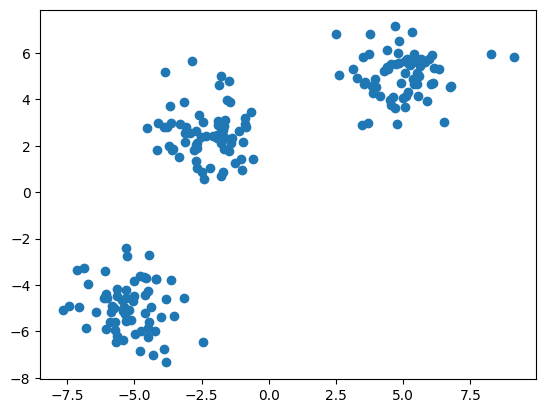

In [79]:
plt.scatter(x[:,0],x[:,1])

In [ ]:
import random
import numpy as np
class KMeans:
    def __init__(self, n_cluster=2, max_iter=100):
       self.n_cluster = n_cluster
       self.max_iter = max_iter 
       self.centroids = None

    def fit_predict(self, x):
        # print(x)
        random_index = random.sample(range(0,x.shape[0]),self.n_cluster)
        self.centroids=x[random_index]
        
        for i in range(self.max_iter):
            #assign cluster
            cluster_group = self.assign_clusters(x)
            # move centroid
            old_centroids=self.centroids
            self.centroids = self.move_centroids(x,cluster_group)
            # check finish
            if (old_centroids == self.centroids).all():
                break
        self.cluster_group=cluster_group
        return cluster_group

    def assign_clusters(self,x):
        cluster_group = []
        distances=[]
        for row in x:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
     
            min_dist= min(distances)
          
            index_pos=distances.index(min_dist)
          
            cluster_group.append(index_pos)
            distances.clear()

        return np.array(cluster_group)

    def move_centroids(self, x,cluster_group):
        new_centroid = []
        cluster_type= np.unique(cluster_group)
        for type in cluster_type:
            new_centroid.append(x[cluster_group==type].mean(axis=0))
        return np.array(new_centroid)
    def inertia_(self,x):
        inertia=0
        for cluster in np.unique(self.cluster_group):
            for row in x[self.cluster_group==cluster]:
                inertia = inertia + np.dot(row-self.centroids[cluster],row-self.centroids[cluster])
        print(inertia)
        return inertia
    

In [95]:
km=KMeans(n_cluster=3,max_iter=100)
y_means=km.fit_predict(x)
km.inertia_(x)

np.float64(429.96846622378047)

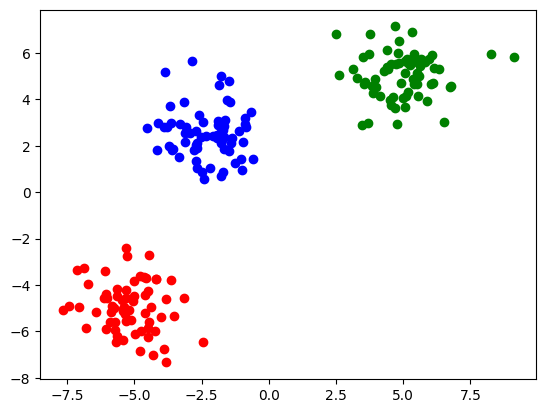

In [96]:
plt.scatter(x[y_means==0,0],x[y_means==0,1],c="red")
plt.scatter(x[y_means==1,0],x[y_means==1,1],c="blue")
plt.scatter(x[y_means==2,0],x[y_means==2,1],c="green")